<a href="https://colab.research.google.com/github/cuboidalstudios/ML_REF_DEF/blob/main/Machine_Learning_REFDEF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **CM2604: Machine Learning REF/DEF**


---
***Bank Marketing - UCI Machine Learning Repository***


https://github.com/cuboidalstudios/ML_REF_DEF/

importing modules for reading data and EDA

In [ ]:
from google.colab import drive

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


replacing csv limiter to comma instead of ;

In [ ]:
f = open("/content/drive/MyDrive/bank-additional-full.csv")
data = f.read()

for i in data:
  if i == ';':
    data = data.replace(i, ',')

f = open("/content/drive/MyDrive/bank-additional-full.csv", "w")
f.write(data)
f.close()

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/bank-additional-full.csv")
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [ ]:
null_sum = df.isna().sum()

duplicate_count = df.duplicated().sum()

print(f"Number of duplicate rows: {duplicate_count}\nNumber of null rows:\n{null_sum}")

Number of duplicate rows: 12
Number of null rows:
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

## Data Cleaning & Feature Engineering

In [ ]:
df = df.drop_duplicates()
df.shape

(41176, 21)

dealing with "Unkwown Values"

In [ ]:
cat_cols = df.select_dtypes(include='object').columns.drop('y')

for col in cat_cols:
    n_unknown = (df[col] == 'unknown').sum()
    if n_unknown > 0:
        print(f"{col}: {n_unknown} unknown values ({n_unknown/len(df)*100:.1f}%)")

job: 330 unknown values (0.8%)
marital: 80 unknown values (0.2%)
education: 1730 unknown values (4.2%)
default: 8596 unknown values (20.9%)
housing: 990 unknown values (2.4%)
loan: 990 unknown values (2.4%)


engineering around the 999 of pdays

In [ ]:
df['was_previously_contacted'] = (df['pdays'] != 999).astype(int)
df[['pdays', 'was_previously_contacted']].head()

,pdays,was_previously_contacted
0,999,0
1,999,0
2,999,0
3,999,0
4,999,0


In [ ]:
# encode target as 0/1 to make plotting/correlation easier later on
df['y_encoded'] = df['y'].map({'yes': 1, 'no': 0})
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,was_previously_contacted,y_encoded
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0,0
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0,0
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0,0
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0,0
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0,0


## Exploratory Data Analysis

### Five Number Summary

In [ ]:
num_cols = ['age', 'duration', 'campaign', 'previous', 'emp.var.rate',
            'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
df[num_cols].describe().loc[['min', '25%', '50%', '75%', 'max']]

,age,duration,campaign,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
min,17.0,0.0,1.0,0.0,-3.4,92.201,-50.8,0.634,4963.6
25%,32.0,102.0,1.0,0.0,-1.8,93.075,-42.7,1.344,5099.1
50%,38.0,180.0,2.0,0.0,1.1,93.749,-41.8,4.857,5191.0
75%,47.0,319.0,3.0,0.0,1.4,93.994,-36.4,4.961,5228.1
max,98.0,4918.0,56.0,7.0,1.4,94.767,-26.9,5.045,5228.1


### Target distribution

In [ ]:
df['y'].value_counts()

,count
y,
no,36537
yes,4639


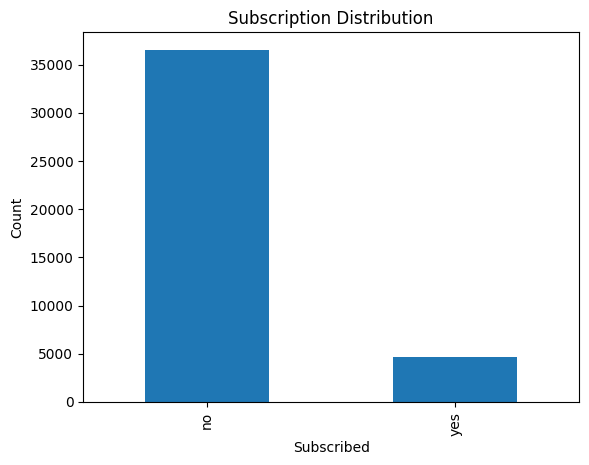

In [ ]:
df['y'].value_counts().plot(kind='bar')
plt.title('Subscription Distribution')
plt.xlabel('Subscribed')
plt.ylabel('Count')
plt.show()

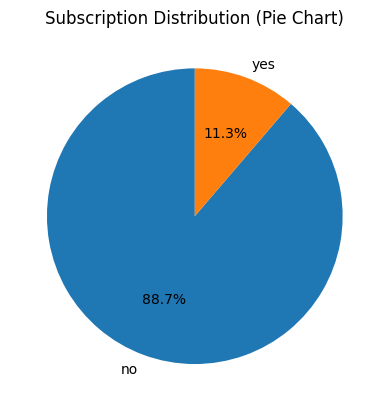

In [ ]:
df['y'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title('Subscription Distribution (Pie Chart)')
plt.ylabel('')
plt.show()

most clients did not subscribe, the classes are very imbalanced

### Age distribution

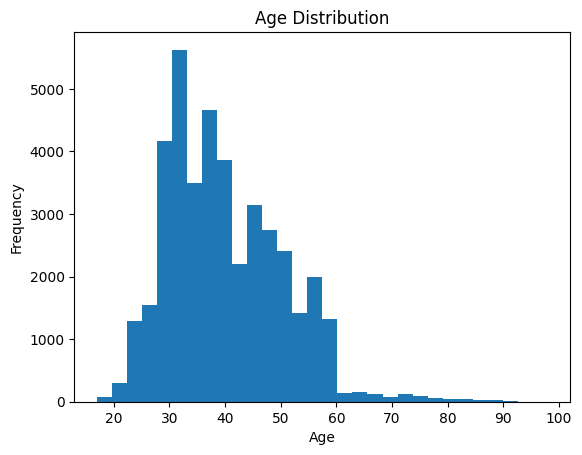

In [ ]:
df['age'].plot(kind='hist', bins=30)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

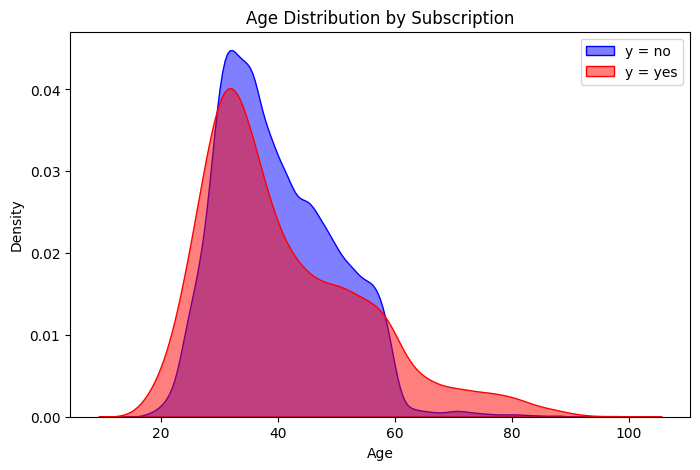

In [ ]:
plt.figure(figsize=(8,5))
sns.kdeplot(data=df[df['y']=='no']['age'], fill=True, color='blue', alpha=0.5, label='y = no')
sns.kdeplot(data=df[df['y']=='yes']['age'], fill=True, color='red', alpha=0.5, label='y = yes')
plt.title('Age Distribution by Subscription')
plt.xlabel('Age')
plt.ylabel('Density')
plt.legend()
plt.show()

age distribution is similar for both groups

### Call duration by subscription

<Figure size 800x500 with 0 Axes>

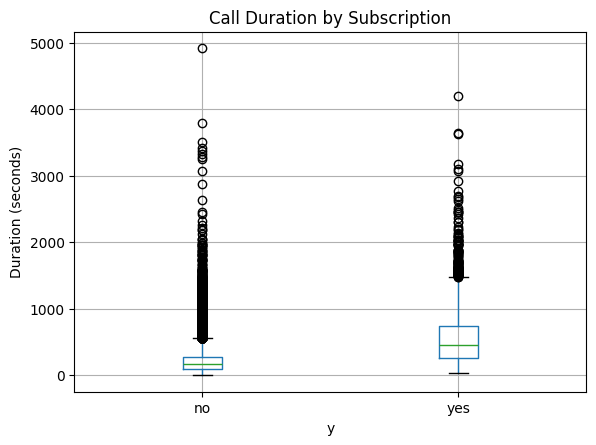

In [ ]:
plt.figure(figsize=(8,5))
df.boxplot(column='duration', by='y')
plt.title('Call Duration by Subscription')
plt.suptitle('')
plt.ylabel('Duration (seconds)')
plt.show()

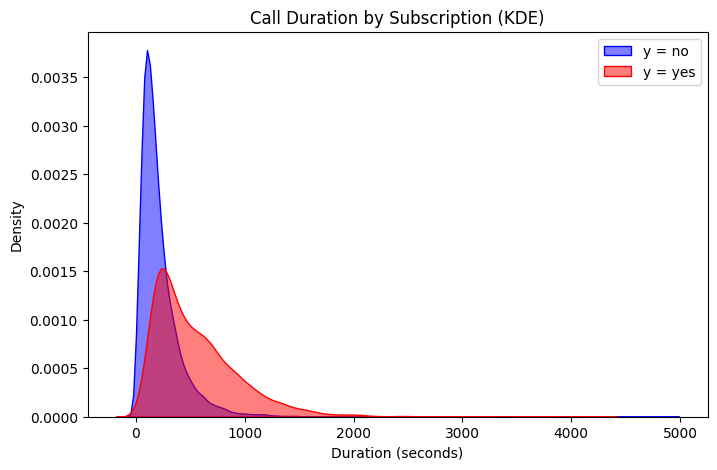

In [ ]:
plt.figure(figsize=(8,5))
sns.kdeplot(data=df[df['y']=='no']['duration'], fill=True, color='blue', alpha=0.5, label='y = no')
sns.kdeplot(data=df[df['y']=='yes']['duration'], fill=True, color='red', alpha=0.5, label='y = yes')
plt.title('Call Duration by Subscription (KDE)')
plt.xlabel('Duration (seconds)')
plt.ylabel('Density')
plt.legend()
plt.show()

In [ ]:
print("correlation between duration and y_encoded:", df['duration'].corr(df['y_encoded']).round(3))

correlation between duration and y_encoded: 0.405


duration is a strong indicator

### Correlation between numeric features

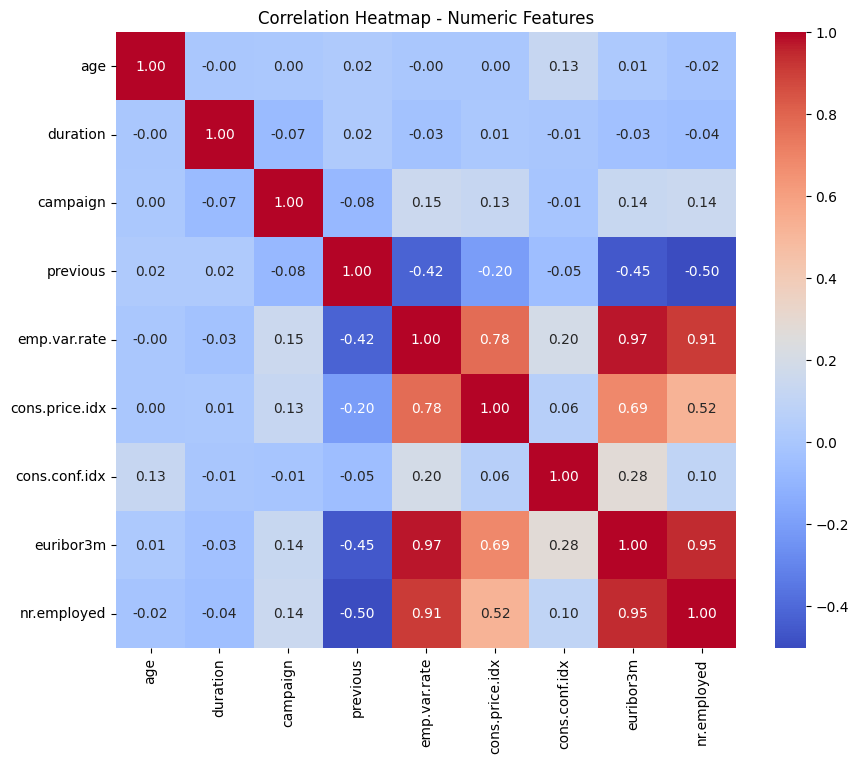

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap - Numeric Features')
plt.show()

### Categorical features vs subscription (Cramer's V)

Cramer's V is used to measure association between two categorical variables, giving a value between 0-1.

| Cramer's V | Strength |
|---|---|
| 0.00 - 0.10 | Negligible |
| 0.11 - 0.20 | Weak |
| 0.21 - 0.34 | Moderate |
| 0.35 - 0.50 | Strong |
| > 0.50 | Very Strong |

In [ ]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    return np.sqrt(phi2 / min(k-1, r-1))

cat_corr = {}
for col in cat_cols:
    cat_corr[col] = cramers_v(df[col], df['y'])

cat_corr = pd.Series(cat_corr).sort_values(ascending=False)
cat_corr

,0
poutcome,0.320520
month,0.274518
job,0.152830
contact,0.144694
default,0.099366
education,0.068436
marital,0.054646
day_of_week,0.025155
housing,0.011809
loan,0.005167


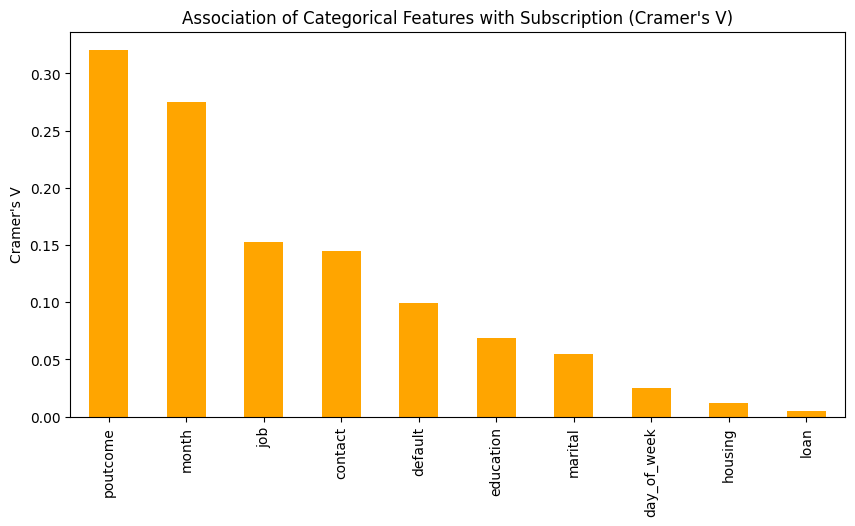

In [ ]:
plt.figure(figsize=(10,5))
cat_corr.plot(kind='bar', color='orange')
plt.title("Association of Categorical Features with Subscription (Cramer's V)")
plt.ylabel("Cramer's V")
plt.show()

### Previous campaign outcome by subscription

<Figure size 800x500 with 0 Axes>

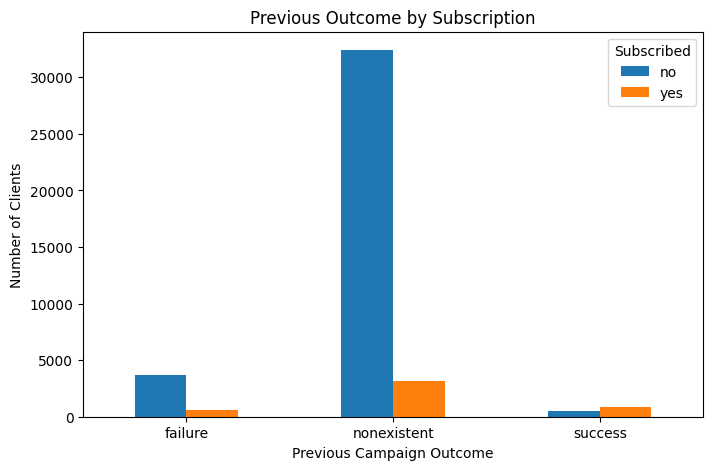

In [ ]:
plt.figure(figsize=(8,5))
poutcome_y = df.groupby(['poutcome', 'y']).size().unstack()
poutcome_y.plot(kind='bar', figsize=(8,5))
plt.title('Previous Outcome by Subscription')
plt.xlabel('Previous Campaign Outcome')
plt.ylabel('Number of Clients')
plt.xticks(rotation=0)
plt.legend(title='Subscribed')
plt.show()

clients who had a successful outcome on a previous campaign are more likely to subscribe again

### Number of previous contacts by subscription

<Figure size 800x500 with 0 Axes>

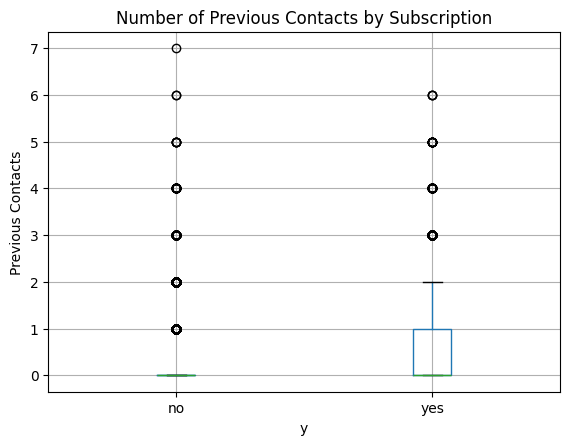

In [ ]:
plt.figure(figsize=(8,5))
df.boxplot(column='previous', by='y')
plt.title('Number of Previous Contacts by Subscription')
plt.suptitle('')
plt.ylabel('Previous Contacts')
plt.show()

### Economic climate vs subscription rate over the campaign

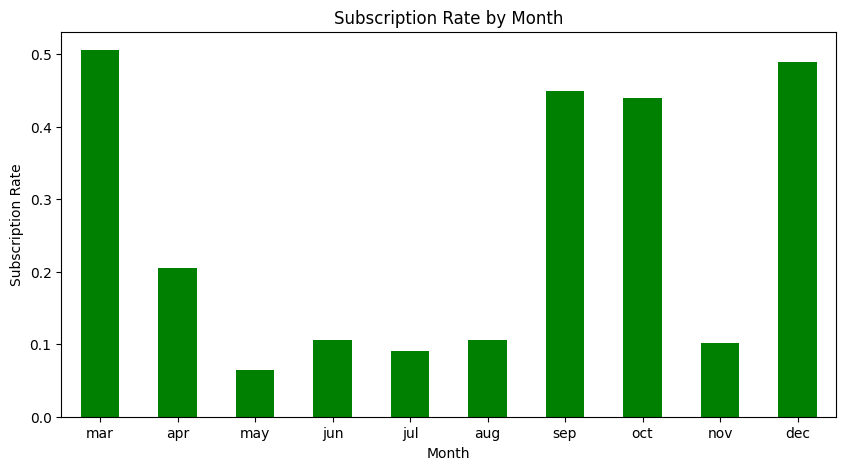

In [ ]:
plt.figure(figsize=(10,5))
df.groupby('month')['y_encoded'].mean().reindex(
    ['mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
).plot(kind='bar', color='green')
plt.title('Subscription Rate by Month')
plt.xlabel('Month')
plt.ylabel('Subscription Rate')
plt.xticks(rotation=0)
plt.show()

### EDA Conclusion

Most clients did not subscribe to a term deposit, the target is imbalanced at roughly 11.3% yes.
Duration stood out as the strongest predictor. Previous campaign outcome and month both show a meaningful association with subscription,
while variables of age are less useful on their own. The economic indicator features are all correlated
with each other since they all describe the same time period, which is expected given they come from
external national statistics rather than the client data itself.

Cramer's V analysis against the actual dataset confirms this: poutcome (0.321) and month (0.275)
are the standout categorical features, landing in the Strong and Moderate bands respectively, while every other
categorical feature (job, contact, default, education, marital, day_of_week, housing, loan) falls into the
weak-to-negligible range (all under 0.16). This matches expectations going in - a client's prior response and
the timing of the call carry far more signal than static demographic attributes. Combined with duration being
unusable for modelling, this points to poutcome, month, and the economic indicators as the features most
worth focusing on for the models, alongside the was_previously_contacted.

---
---

# Machine Learning Coursework - Task 2
* Neural Network Model
* Decision Tree Model



## Importing Libraries

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    f1_score, precision_score, recall_score, accuracy_score,
    roc_auc_score, classification_report, ConfusionMatrixDisplay
)
from scipy.stats import uniform

## Load Dataset

In [ ]:
drive.mount('/content/drive')

df = pd.read_csv("/content/drive/MyDrive/bank-additional-full.csv")
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## Data Pre-processing

### Data Cleaning

In [ ]:
df = df.drop_duplicates()

df['was_previously_contacted'] = (df['pdays'] != 999).astype(int)

# dropping duration here - explained in the EDA notebook/report, it causes data leakage since its
# only known after the call has already happened
df = df.drop('duration', axis=1)

df.shape

(41176, 21)

### Feature Engineering

In [ ]:
# target
df['y'] = df['y'].map({'yes': 1, 'no': 0})

# categorical columns to one-hot encode, unknown is kept in as its own category rather than
# dropped/imputed since removing it wouldve cost us a decent chunk of the default column especially
cat_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan',
            'contact', 'month', 'day_of_week', 'poutcome']

df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

y = df['y']
X = df.drop('y', axis=1)

X.shape

(41176, 53)

## Hyperparameter tuning (Decision Tree)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

dt = DecisionTreeClassifier(class_weight='balanced', random_state=42)

dt_params = {
    "criterion": ["gini", "entropy"],
    "max_depth": [None, 5, 10, 20, 30],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8]
}

dt_grid = GridSearchCV(
    estimator=dt,
    param_grid=dt_params,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

dt_grid.fit(X_train, y_train)

print("Best Decision Tree Parameters:")
print(dt_grid.best_params_)
print("\nBest F1 Score:", dt_grid.best_score_)

Best Decision Tree Parameters:
{'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 20}

Best F1 Score: 0.4603069798370649


## Hyperparameter tuning (Neural Network)

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

mlp = MLPClassifier(max_iter=500, random_state=42)

nn_params = {
    "hidden_layer_sizes": [(16,), (32,), (64,), (32,16), (64,32)],
    "activation": ["relu", "tanh"],
    "solver": ["adam", "sgd"],
    "alpha": uniform(0.0001, 0.01),
    "learning_rate_init": uniform(0.0001, 0.01)
}

nn_random = RandomizedSearchCV(
    estimator=mlp,
    param_distributions=nn_params,
    n_iter=20,
    cv=5,
    scoring="f1",
    random_state=42,
    n_jobs=-1
)

nn_random.fit(X_train_scaled, y_train)

print("Best Neural Network Parameters:")
print(nn_random.best_params_)
print("\nBest F1 Score:", nn_random.best_score_)

Training samples: 32940
Testing samples: 8236
Best Neural Network Parameters:
{'activation': 'relu', 'alpha': np.float64(0.00398677289689482), 'hidden_layer_sizes': (32,), 'learning_rate_init': np.float64(0.005496921323890798), 'solver': 'sgd'}

Best F1 Score: 0.38298663572442787


## Final Decision Tree Model

In [ ]:
dt_best = dt_grid.best_estimator_

y_pred_dt = dt_best.predict(X_test)

print("F1 Score:", f1_score(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))

F1 Score: 0.4813141683778234

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.87      0.91      7308
           1       0.39      0.63      0.48       928

    accuracy                           0.85      8236
   macro avg       0.67      0.75      0.70      8236
weighted avg       0.89      0.85      0.86      8236



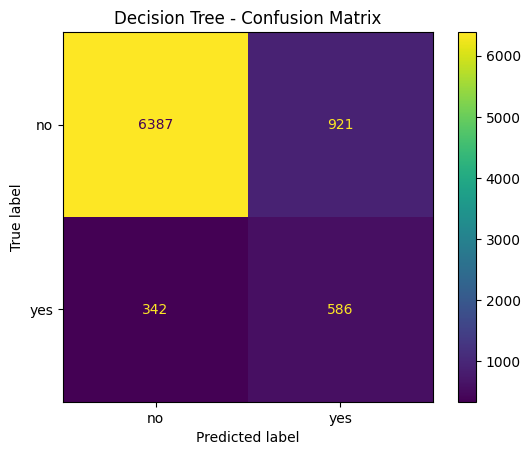

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dt, display_labels=['no', 'yes'])
plt.title('Decision Tree - Confusion Matrix')
plt.show()

## Final Neural Network Model

In [ ]:
nn_best = nn_random.best_estimator_

y_pred_nn = nn_best.predict(X_test_scaled)

print("F1 Score:", f1_score(y_test, y_pred_nn))
print("\nClassification Report:\n", classification_report(y_test, y_pred_nn))

F1 Score: 0.38611713665943603

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.97      0.94      7308
           1       0.59      0.29      0.39       928

    accuracy                           0.90      8236
   macro avg       0.75      0.63      0.66      8236
weighted avg       0.88      0.90      0.88      8236



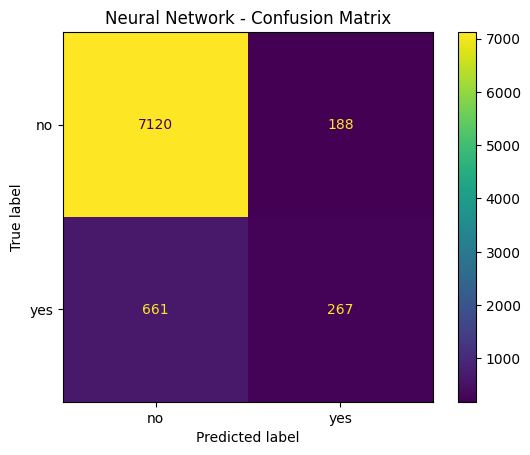

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_nn, display_labels=['no', 'yes'])
plt.title('Neural Network - Confusion Matrix')
plt.show()

## Model Comparison

In [ ]:
dt_probs = dt_best.predict_proba(X_test)[:, 1]
nn_probs = nn_best.predict_proba(X_test_scaled)[:, 1]

results = pd.DataFrame({
    "Model": ["Decision Tree", "Neural Network"],
    "Accuracy": [accuracy_score(y_test, y_pred_dt), accuracy_score(y_test, y_pred_nn)],
    "Precision": [precision_score(y_test, y_pred_dt), precision_score(y_test, y_pred_nn)],
    "Recall": [recall_score(y_test, y_pred_dt), recall_score(y_test, y_pred_nn)],
    "F1 Score": [f1_score(y_test, y_pred_dt), f1_score(y_test, y_pred_nn)],
    "ROC-AUC": [roc_auc_score(y_test, dt_probs), roc_auc_score(y_test, nn_probs)]
})

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Decision Tree,0.846649,0.388852,0.631466,0.481314,0.792327
1,Neural Network,0.896916,0.586813,0.287716,0.386117,0.785423


We can see The Decision Tree achieves higher recall (0.631 over 0.288) but lower precision (0.389 over 0.587). The Neural Network achieves higher accuracy (0.897 over 0.847) and precision but lower recall. The Decision Tree also has a higher F1 score (0.481 over 0.386) and a marginally higher ROC-AUC (0.792 over 0.785).

For this use case, recall can be used as the most important metric, since contacting a client who declines costs a phone call, while failing to contact a likely subscriber is a missed sale. Therefore, the Decision Tree approach is the better model, supported by a higher F1 and ROC-AUC, its interpretability, and its faster training time compared to the Neural Network. The recommended model is the Decision Tree with gini criterion, max_depth=5, min_samples_leaf=4, and min_samples_split=20.
